# 01b — The 0.999 mystery: a data-leak investigation

Notebook 01 trained a plain CNN on stacked signature pairs and reported **ROC-AUC 0.999
on writers it had never seen**. That should stop us in our tracks.

The whole point of notebook 01 was to be the *weak* baseline — the naive approach we
build on. A weak baseline that scores 0.999 on unseen people is not a success, it's a
**red flag**. Either signature verification is trivially easy (it isn't — it's a hard
biometric problem), or our model found a shortcut and is getting the right answer for
the wrong reason.

This notebook is the investigation. No deep learning here — just `pandas` and a couple
of tiny `scikit-learn` probes. The goal is to find out *what* the model actually learned,
prove it, fix the data, and prove the fix works.

**The punchline up front:** the label can be predicted from the *questioned* image alone,
without ever looking at the reference. The model never learned to compare signatures. We
fix it by changing how pairs are built.

## 1. Setup

Resolve the dataset path whether we're local or on Colab (after `git clone`).

In [1]:
import os, glob, re, hashlib, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

def find_root():
    for c in ['sign_data', '../sign_data', 'Signature-forgery-verification/sign_data']:
        if os.path.isdir(c):
            return c
    raise FileNotFoundError('sign_data not found — on Colab, git clone the repo first.')

DATA_ROOT = find_root()
IMG_DIR   = os.path.join(DATA_ROOT, 'train')
print('dataset root:', DATA_ROOT)

dataset root: ../sign_data


## 2. The suspect

Re-create exactly the pair table notebook 01 trained on: combine both CSVs, drop the
duplicate rows, and derive the writer id from the path. Columns are `(img1, img2, label)`
where **`img1` is the reference signature** and **`img2` is the questioned one**.

In [2]:
cols = ['img1', 'img2', 'label']
df = pd.concat([pd.read_csv(os.path.join(DATA_ROOT, 'train_data.csv'), header=None, names=cols),
                pd.read_csv(os.path.join(DATA_ROOT, 'test_data.csv'),  header=None, names=cols)])
df = df.drop_duplicates().reset_index(drop=True)
df['writer'] = df['img1'].str.split('/').str[0].astype(int)

print('total unique pairs:', len(df))
print(df['label'].value_counts().rename({0: 'label 0 (match)', 1: 'label 1 (forgery)'}))
df.head()

total unique pairs: 23206
label
label 0 (match)      12602
label 1 (forgery)    10604
Name: count, dtype: int64


,img1,img2,label,writer
0,068/09_068.png,068_forg/03_0113068.PNG,1,68
1,068/09_068.png,068_forg/01_0124068.PNG,1,68
2,068/09_068.png,068_forg/02_0124068.PNG,1,68
3,068/09_068.png,068_forg/01_0113068.PNG,1,68
4,068/09_068.png,068_forg/04_0124068.PNG,1,68


## 3. First probe — where does `img2` come from?

Before any model, just *look at the data*. In this dataset a genuine signature lives in a
folder like `049/` and a forgery in `049_forg/`. Let's ask a blunt question: **is the
label simply a function of which folder `img2` sits in?**

In [3]:
df['img2_is_forg'] = df['img2'].str.split('/').str[0].str.contains('forg').astype(int)
df['img1_is_forg'] = df['img1'].str.split('/').str[0].str.contains('forg').astype(int)

print('Does img1 ever come from a _forg folder?', bool(df['img1_is_forg'].any()))
print()
print('crosstab — rows = label, cols = img2 sits in a _forg folder:')
print(pd.crosstab(df['label'], df['img2_is_forg']))

Does img1 ever come from a _forg folder? False

crosstab — rows = label, cols = img2 sits in a _forg folder:
img2_is_forg      0      1
label                     
0             12602      0
1                 0  10604


Read that table carefully. It's perfectly diagonal:

- every `label = 0` (match) pair has a **genuine** `img2`
- every `label = 1` (forgery) pair has a **forged** `img2`
- `img1` is *never* a forgery — it's always a genuine reference

So `label = 1`  ⟺  `img2` is in a `_forg` folder. **No exceptions.** The answer is
literally written on the folder `img2` came from. A model doesn't need to compare the two
signatures at all — it just needs to recognise "does `img2` look forged?"

## 4. Proving the shortcut — train on ONE image, ignore the other

A crosstab shows the leak *exists*. To show the model actually *uses* it, we run two
deliberately crippled probes on the held-out writers (049+), using a small gradient-boosted
classifier on raw downscaled pixels:

- **`img1`-only:** see only the reference signature. Since `img1` is always genuine, it
  carries no information about the label → should score ~0.5 (chance).
- **`img2`-only:** see only the questioned signature. If the shortcut is real, this alone
  should score *well*, despite never seeing what it's being compared against.

Neither probe is ever shown both images, so neither can "compare" anything.

In [4]:
def sample_balanced(frame, n, seed=42):
    g = frame[frame.label == 0].sample(min(n//2, (frame.label==0).sum()), random_state=seed)
    f = frame[frame.label == 1].sample(min(n//2, (frame.label==1).sum()), random_state=seed)
    return pd.concat([g, f]).sample(frac=1, random_state=seed)

# writer-independent split (same protocol as the real notebooks)
train_df = df[df.writer <= 40]
test_df  = df[df.writer >= 49]

def load_single(frame, col, H=60, W=90):
    X, y = [], []
    for _, r in frame.iterrows():
        im = cv2_imread_gray(os.path.join(IMG_DIR, r[col]))
        if im is None:
            continue
        X.append(cv2_resize(im, W, H).astype('float32').ravel() / 255.0)
        y.append(r['label'])
    return np.array(X), np.array(y)

We load in grayscale with OpenCV (same as notebook 01), via two tiny helpers:

In [5]:
import cv2
def cv2_imread_gray(path):
    return cv2.imread(path, cv2.IMREAD_GRAYSCALE)
def cv2_resize(im, W, H):
    return cv2.resize(im, (W, H))

In [6]:
tr = sample_balanced(train_df, 3000)
te = sample_balanced(test_df,  2000)

results = {}
for col in ['img1', 'img2']:
    Xtr, ytr = load_single(tr, col)
    Xte, yte = load_single(te, col)
    clf = HistGradientBoostingClassifier(max_iter=200, random_state=42).fit(Xtr, ytr)
    p = clf.predict_proba(Xte)[:, 1]
    results[col] = roc_auc_score(yte, p)
    print(f'{col}-only  ->  AUC on unseen writers: {results[col]:.3f}')

print()
print('img1 (reference) alone :', round(results['img1'], 3), '  <- ~0.5 = chance, as predicted')
print('img2 (questioned) alone:', round(results['img2'], 3), '  <- high WITHOUT ever seeing the reference')

img1-only  ->  AUC on unseen writers: 0.493


img2-only  ->  AUC on unseen writers: 0.913

img1 (reference) alone : 0.493   <- ~0.5 = chance, as predicted
img2 (questioned) alone: 0.913   <- high WITHOUT ever seeing the reference


**This is the proof.** A model that never sees the reference signature still separates
genuine from forged on people it never trained on. The reference image is dead weight; the
questioned image leaks the answer. Notebook 01's CNN is just a stronger version of this
`img2`-only probe — which is why it pushed the number all the way to 0.999.

Why does the shortcut survive the writer-independent split? Because forgery *artifacts*
(hesitation, pen-lifts, the forger's own motor habits) are **generic across people**. "Looks
forged" transfers to new writers, so the split — which correctly prevents memorising
specific people — does nothing to stop this particular leak.

## 5. The fix — make `img2` uninformative on its own

The leak exists because of *how pairs were built*. There are only two recipes in the CSV:

| recipe | img1 | img2 | label |
|---|---|---|---|
| match    | genuine of A | genuine of A | 0 |
| forgery  | genuine of A | forgery of A | 1 |

Every genuine `img2` is a match; every forged `img2` is a non-match. So "is `img2` genuine?"
== "is it a match?". We break that by adding a **third recipe**: two genuine signatures from
*different writers*. That's a non-match (`label = 1`) where `img2` is **genuine**.

| recipe | img1 | img2 | label | teaches |
|---|---|---|---|---|
| match            | genuine of A | genuine of A          | 0 | same hand → same |
| hard negative    | genuine of A | forgery of A          | 1 | skilled fake is still not A |
| **random negative (NEW)** | genuine of A | genuine of **B** | 1 | different person → different |

Now a genuine `img2` can be *either* label, so "is `img2` genuine?" tells you nothing. The
only way to get the label right is to actually compare `img1` against `img2`.

We generate these from the raw per-writer folders, because the new recipe simply doesn't
exist in the CSV.

In [7]:
# index the folders: genuine[w] = list of genuine files, forg[w] = list of forgery files
genuine, forg = {}, {}
for d in sorted(os.listdir(IMG_DIR)):
    full = os.path.join(IMG_DIR, d)
    if not os.path.isdir(full):
        continue
    files = [os.path.join(d, f) for f in os.listdir(full) if f.lower().endswith(('.png', '.jpg'))]
    if d.endswith('_forg'):
        forg[int(d.replace('_forg', ''))] = files
    else:
        genuine[int(d)] = files

writers = sorted(set(genuine) & set(forg))
print('writers with both genuine and forgery folders:', len(writers))

def make_pairs(wset, per_writer, seed=42):
    rng = random.Random(seed)
    wlist = sorted(wset)
    rows = []
    for w in wlist:
        g = genuine.get(w, [])
        if len(g) < 2:
            continue
        for _ in range(per_writer):                      # match (label 0)
            a, b = rng.sample(g, 2)
            rows.append((a, b, 0))
        for _ in range(per_writer // 2):                 # hard negative: forgery of w
            if forg.get(w):
                rows.append((rng.choice(g), rng.choice(forg[w]), 1))
        for _ in range(per_writer // 2):                 # random negative: different writer
            other = rng.choice([x for x in wlist if x != w])
            rows.append((rng.choice(g), rng.choice(genuine[other]), 1))
    rng.shuffle(rows)
    return pd.DataFrame(rows, columns=['img1', 'img2', 'label'])

train_writers = [w for w in writers if w <= 40]
test_writers  = [w for w in writers if w >= 49]
fixed_tr = make_pairs(train_writers, per_writer=80)
fixed_te = make_pairs(test_writers,  per_writer=80)
print('fixed train pairs:', len(fixed_tr), '| label balance:', dict(fixed_tr.label.value_counts()))
print('fixed test  pairs:', len(fixed_te), '| label balance:', dict(fixed_te.label.value_counts()))

writers with both genuine and forgery folders: 64
fixed train pairs: 5600 | label balance: {0: np.int64(2800), 1: np.int64(2800)}
fixed test  pairs: 3360 | label balance: {0: np.int64(1680), 1: np.int64(1680)}


## 6. Does the fix actually kill the shortcut?

We check two things, because the answer is more interesting than a single number.

**(a) Full rebuilt pairs, `img2`-only.** This *won't* drop all the way to 0.5, and that's
expected: half of our non-matches are still forgeries, and a forged `img2` is still always a
non-match. So a forgery detector remains a *partial* signal. The point is it's no longer
*sufficient* — it can't tell a match from a different-writer non-match, because both have a
genuine `img2`.

**(b) The clean test — genuine questioned images only.** Throw away the forgery non-matches
and keep only pairs where `img2` is genuine. Now `label 0` = same writer, `label 1` =
different writer, and **both have a genuine `img2`**. If `img2`-only scores ~0.5 here, the
questioned image carries no match/non-match information on its own — the model is *forced* to
compare it against the reference. This is the real proof.

In [8]:
# (a) full rebuilt pairs, img2-only
def load_single_df(frame, col, H=60, W=90):
    X, y = [], []
    for _, r in frame.iterrows():
        im = cv2_imread_gray(os.path.join(IMG_DIR, r[col]))
        if im is None:
            continue
        X.append(cv2_resize(im, W, H).astype('float32').ravel() / 255.0)
        y.append(r['label'])
    return np.array(X), np.array(y)

Xtr, ytr = load_single_df(fixed_tr, 'img2')
Xte, yte = load_single_df(fixed_te, 'img2')
clf = HistGradientBoostingClassifier(max_iter=200, random_state=42).fit(Xtr, ytr)
auc_full = roc_auc_score(yte, clf.predict_proba(Xte)[:, 1])

# (b) genuine-img2 subset only: match (same writer) vs non-match (different writer)
gen_tr = fixed_tr[~fixed_tr.img2.str.contains('_forg')]
gen_te = fixed_te[~fixed_te.img2.str.contains('_forg')]
Xtr, ytr = load_single_df(gen_tr, 'img2')
Xte, yte = load_single_df(gen_te, 'img2')
clf = HistGradientBoostingClassifier(max_iter=200, random_state=42).fit(Xtr, ytr)
auc_gen = roc_auc_score(yte, clf.predict_proba(Xte)[:, 1])

print('ORIGINAL leaky pairs,  img2-only            :', round(results['img2'], 3))
print('REBUILT pairs,         img2-only (all)      :', round(auc_full, 3),
      '  <- partial forgery signal remains, but not sufficient')
print('REBUILT pairs,         img2-only (genuine-only):', round(auc_gen, 3),
      '  <- ~0.5: match vs non-match is NO LONGER leaked => fix works')

ORIGINAL leaky pairs,  img2-only            : 0.913
REBUILT pairs,         img2-only (all)      : 0.694   <- partial forgery signal remains, but not sufficient
REBUILT pairs,         img2-only (genuine-only): 0.524   <- ~0.5: match vs non-match is NO LONGER leaked => fix works


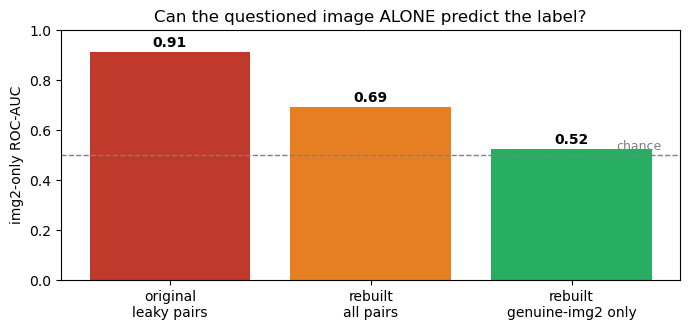

In [9]:
# one picture worth keeping
fig, ax = plt.subplots(figsize=(7, 3.4))
labels = ['original\nleaky pairs', 'rebuilt\nall pairs', 'rebuilt\ngenuine-img2 only']
vals   = [results['img2'], auc_full, auc_gen]
bars = ax.bar(labels, vals, color=['#c0392b', '#e67e22', '#27ae60'])
ax.axhline(0.5, ls='--', c='gray', lw=1)
ax.text(2.45, 0.52, 'chance', color='gray', ha='right', fontsize=9)
ax.set_ylabel('img2-only ROC-AUC'); ax.set_ylim(0, 1)
ax.set_title('Can the questioned image ALONE predict the label?')
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.02, f'{v:.2f}', ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

## 7. A cleaner dataset — the NFI set (`sign_data_nfi`)

There's a second signature set in this repo, `sign_data_nfi` (a deduplicated, resized
subset of the NFI `sample_Signature` collection). Its filenames encode **who signed** and
**whose signature it's meant to be** — `NFI-XXXYYZZZ`, genuine ⟺ `XXX == ZZZ`. Forgeries
are *targeted*: someone deliberately imitating a specific person.

Does the `img2`-only shortcut work there too? We build the classic genuine-vs-forgery pairs
(the leaky recipe) and probe.

In [10]:
nfi = None
for c in ['sign_data_nfi', '../sign_data_nfi', 'Signature-forgery-verification/sign_data_nfi']:
    if os.path.isdir(c):
        nfi = c; break

if nfi is None:
    print('sign_data_nfi not found — skipping (clone the repo to run this section).')
else:
    def parse(fn):
        s = re.sub(r'^NFI-', '', os.path.basename(fn)); s = os.path.splitext(s)[0]
        return (s[:3], s[5:8]) if re.fullmatch(r'\d{8}', s) else None

    g_by_owner, f_by_owner = {}, {}
    for f in glob.glob(os.path.join(nfi, 'genuine', '*')):
        p = parse(f);  g_by_owner.setdefault(p[1], []).append(f) if p else None
    for f in glob.glob(os.path.join(nfi, 'forged', '*')):
        p = parse(f);  f_by_owner.setdefault(p[1], []).append(f) if p else None

    owners = sorted(set(g_by_owner) & set(f_by_owner), key=int)
    tr_o, te_o = owners[:18], owners[18:]
    print('NFI owners:', len(owners), '| train', len(tr_o), '| test', len(te_o))

    def nfi_img2_probe(owner_set, seed=42):
        rng = random.Random(seed); rows = []
        for o in owner_set:
            g = g_by_owner[o]
            for x in g[1:]:               rows.append((x, 0))      # genuine img2  (match)
            for x in f_by_owner.get(o, []): rows.append((x, 1))    # forged img2   (non-match)
        X = np.array([cv2_resize(cv2_imread_gray(fn), 90, 60).astype('float32').ravel()/255. for fn,_ in rows])
        y = np.array([l for _, l in rows])
        return X, y

    Xtr, ytr = nfi_img2_probe(tr_o); Xte, yte = nfi_img2_probe(te_o)
    clf = HistGradientBoostingClassifier(max_iter=200, random_state=42).fit(Xtr, ytr)
    auc_nfi = roc_auc_score(yte, clf.predict_proba(Xte)[:, 1])
    print('img2-only AUC on NFI (leaky recipe!):', round(auc_nfi, 3),
          '  <- ~0.5 even with genuine-vs-forgery pairs')

NFI owners: 30 | train 18 | test 12


img2-only AUC on NFI (leaky recipe!): 0.584   <- ~0.5 even with genuine-vs-forgery pairs


The same leaky recipe that scored ~0.9 on `sign_data` scores ~chance here. Because NFI
forgeries are *targeted imitations*, "looks forged" is no longer a giveaway — a good forgery
is supposed to look genuine. That makes `sign_data_nfi` an honest, independent **cross-dataset
test set** for the later notebooks, even though it's small (30 writers).

## 8. What we learned, and what changes downstream

**The bug.** Notebook 01's 0.999 was a *label leak*, not skill. The pairing made the label a
deterministic function of the questioned image's folder, so the model learned a generic
"forgery detector" and ignored the reference entirely. The writer-independent split didn't
catch it because forgery artifacts generalise across people.

**The lesson.** A suspiciously good number from a model that *shouldn't* be that good is a
signal to investigate the data, not to celebrate. The cheapest possible probe — predict the
label from one image with a linear/tree model — exposed it in seconds, no GPU required.

**The fix.** Add genuine-vs-different-writer negatives so a genuine `img2` no longer implies
"match". A forged `img2` is still always a non-match, so a forgery detector stays a *partial*
signal — but no longer *sufficient*: on the genuine-only subset (match vs different-writer,
both genuine `img2`) the `img2`-only probe falls to ~0.5, so the model is *forced* to
compare the two signatures.

**Downstream (notebooks 02 & 03).** These build pairs the same leaky way, so they inherit a
milder version of the same problem. The `make_pairs` function here is the template they
should use. And `sign_data_nfi` gives us a clean second source to report **cross-dataset**
metrics — the most credible evaluation this project can show.

Notebook 01 stays exactly as it is: the honest, naive baseline whose impressive-looking
score is the whole reason this investigation exists.